<a href="https://colab.research.google.com/github/MarianaCastrillonM004/Integracion-de-prospectiva-y-datos/blob/main/Parcial1_MedicalAttenttion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**CASO DE ESTUDIO - ATENCIÓN MÉDICA**

Una entidad prestadora de salud quiere saber cual es la sucursal de atención que tiene una mayor afinidad con la sucursal que se quiere cerrar (Sabaneta).

Para determinar esta afinidad, la entidad prestadora de salud quiere llevar a cabo la estimación de la credibilidad entre la sucursal a cerrar y las demás sucursales utilizando la variable de referencia seleccionada.

Para reubicar a sus pacientes, la entidad prestadora de salud quiere clasificar sus pacientes en las otras sucursales mediante el método del valor de pertenencia.

Debido a que la entidad en salud tiene dudas frente al método de credibilidad y de integración por valor de pertenencia, la entidad prestadora de salud quiere hacer el mismo procedimiento de integración de pacientes mediante la utilización del método de aceptación y rechazo.

Es importante para antes y después de la integración de los datos, llevar a cabo el análisis de las medidas de tendencia central y dispersión para cada una de las bases de datos, para antes y después de la integración de los nuevos pacientes


DISCLAIMER: Para la realización del código usado, agregué una columna de glucosa en la sucursal de Itaguí con números aleatorios y así poder usar esa variable como referencia. Por ello, si quiere pobrar el código, le recomiendo descargar el excel que esta en el mismo repositorio de github con el nombre de "3. Parcial - medical_attention_data.xlsx"

0. Se procede con la carga de las librerias

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Definicion de funciones para la caracterizacion de medidas de tendencia central y simetría y parametros de riesgo

In [3]:
#@title Caracterización de Distribuciones de Probabilidad
def caracterizacion(DIAB):

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(DIAB,bins=NI)
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  df.head(10)

  #Se procede con la estimación de la media
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  return u,sigma,Cas,Kur,df

In [4]:
# @title Parametros de Riesgo
def RiskParameters(DIAB):

  NDT=len(DIAB)
  PE=np.mean(DIAB)
  NPE=np.sum(DIAB<PE)
  OpVar=np.percentile(DIAB,99.9)
  NPC=np.sum(DIAB>OpVar)
  NPNE=NDT-NPE-NPC

  return OpVar,NPE,NPNE,NPC

2. Carga de archivos

In [5]:
#Cargamos el archivo y determinamos las variables
nxl='/content/drive/MyDrive/UNIVERSIDAD/Enfasis/Archivos I&P/3. Parcial - medical_attention_data.xlsx'
XDBo=pd.read_excel(nxl,sheet_name='Sabaneta')
XDBe1=pd.read_excel(nxl,sheet_name='Bello')
XDBe2=pd.read_excel(nxl,sheet_name='Medellín')
XDBe3=pd.read_excel(nxl,sheet_name='Envigado')
XDBe4=pd.read_excel(nxl,sheet_name='Itagui')
XDBe5=pd.read_excel(nxl,sheet_name='Caldas')

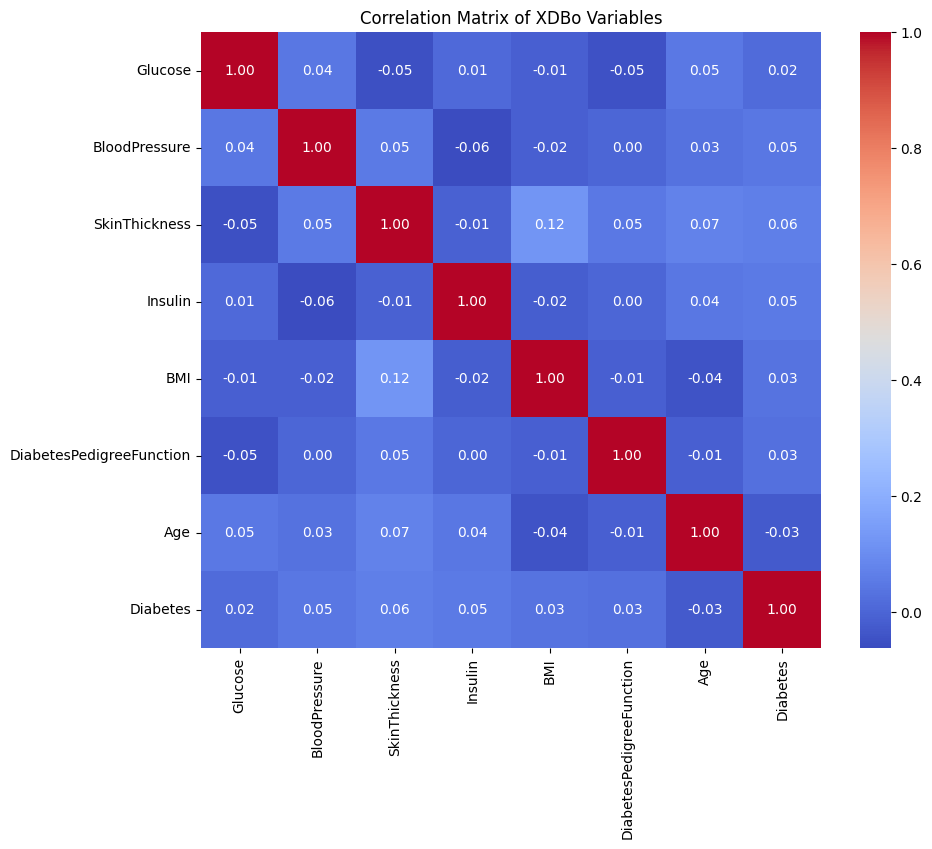

In [6]:
#Hacemos matriz de correlación para detreminar la variable de referencia
correlation_matrix = XDBo.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of XDBo Variables')
plt.show()

Se construyó la matriz de correlación entre todas las variables continuas y la variable Diabetes. Aunque las correlaciones son bajas en este dataset balanceado, se seleccionó Glucose como variable de referencia por ser el principal indicador clínico de diabetes

3. Cálculo de valores estadísticos según variable de glucosa

In [7]:
def process_branch_data(branch_df, branch_name):
    # Extractaemos la columna de glucosa
    DIA = branch_df.iloc[:, 1]

    # Applicamos la función de caracterización
    u, sigma, Cas, Kur, df_char = caracterizacion(DIA)

    # Aplicamos la función de parámetros de riesgo
    OpVar, NPE, NPNE, NPC = RiskParameters(DIA)

    print(f"\n--- Results for {branch_name} ---")
    print(f"Characterization: Mean={u:.2f}, StdDev={sigma:.2f}, Skewness={Cas:.2f}, Kurtosis={Kur:.2f}")
    print(f"Risk Parameters: OpVar={OpVar:.2f}, NPE={NPE}, NPNE={NPNE}, NPC={NPC}")

    return u, sigma, Cas, Kur, df_char, OpVar, NPE, NPNE, NPC

# Procesamos los resultados de cada sucursal
uo, sigmao, Caso, Kuro, dfo, OpVaro, NPEo, NPNEo, NPCo = process_branch_data(XDBo, 'Sabaneta')
ue1, sigmae1, Case1, Kure1, dfe1, OpVare1, NPEe1, NPNEe1, NPCe1 = process_branch_data(XDBe1, 'Bello')
ue2, sigmae2, Case2, Kure2, dfe2, OpVare2, NPEe2, NPNEe2, NPCe2 = process_branch_data(XDBe2, 'Medellín')
ue3, sigmae3, Case3, Kure3, dfe3, OpVare3, NPEe3, NPNEe3, NPCe3 = process_branch_data(XDBe3, 'Envigado')
ue4, sigmae4, Case4, Kure4, dfe4, OpVare4, NPEe4, NPNEe4, NPCe4 = process_branch_data(XDBe4, 'Itagui')
ue5, sigmae5, Case5, Kure5, dfe5, OpVare5, NPEe5, NPNEe5, NPCe5 = process_branch_data(XDBe5, 'Caldas')


--- Results for Sabaneta ---
Characterization: Mean=116.61, StdDev=45.62, Skewness=0.11, Kurtosis=-1.20
Risk Parameters: OpVar=200.00, NPE=313, NPNE=308, NPC=0

--- Results for Bello ---
Characterization: Mean=119.39, StdDev=46.85, Skewness=0.01, Kurtosis=-1.28
Risk Parameters: OpVar=200.00, NPE=242, NPNE=260, NPC=0

--- Results for Medellín ---
Characterization: Mean=122.64, StdDev=46.46, Skewness=-0.07, Kurtosis=-1.24
Risk Parameters: OpVar=200.00, NPE=435, NPNE=460, NPC=0

--- Results for Envigado ---
Characterization: Mean=120.91, StdDev=44.63, Skewness=-0.01, Kurtosis=-1.19
Risk Parameters: OpVar=200.00, NPE=399, NPNE=393, NPC=0

--- Results for Itagui ---
Characterization: Mean=121.68, StdDev=47.29, Skewness=-0.01, Kurtosis=-1.27
Risk Parameters: OpVar=200.00, NPE=345, NPNE=339, NPC=0

--- Results for Caldas ---
Characterization: Mean=123.39, StdDev=46.49, Skewness=-0.07, Kurtosis=-1.26
Risk Parameters: OpVar=200.00, NPE=459, NPNE=450, NPC=0


Segun estos resultados, todas las sucursales tienen valores muy similares (media y std) y la curtosis además del std nos indica que los valores están muy dispersos. Signififica que nuestra distribucion es mas como un cuadrado que otra cosa.

4. Teoría de la credibilidad

In [8]:
def calculate_credibility(uo, sigmao, NDo, ue, sigmae, NDe):
    EPV = (sigmao * NDo + sigmae * NDe) / (NDo + NDe)

    # Valor hipotético de la media (VHM)
    uh = (uo * NDo + ue * NDe) / (NDo + NDe)
    VHM = ((NDo * uo**2 + NDe * ue**2) / (NDo + NDe)) - uh**2
    if VHM == 0:
        fc = float('inf')
    else:
        fc = EPV / VHM
    if NDo + fc == 0:
        Cr = 0 # No debería pasar si NDo > 0 y fc >= 0
    else:
        Cr = NDo / (NDo + fc)
    return Cr, uh


# contamos número de pacientes en la sucursal de sabaneta
NDo_sabaneta = len(XDBo.iloc[:, 1])

# Hacemos una lista de variables estadisticas de otras sucursales
external_branches = [
    {'name': 'Bello', 'df': XDBe1, 'u': ue1, 'sigma': sigmae1},
    {'name': 'Medellín', 'df': XDBe2, 'u': ue2, 'sigma': sigmae2},
    {'name': 'Envigado', 'df': XDBe3, 'u': ue3, 'sigma': sigmae3},
    {'name': 'Itagui', 'df': XDBe4, 'u': ue4, 'sigma': sigmae4},
    {'name': 'Caldas', 'df': XDBe5, 'u': ue5, 'sigma': sigmae5}
]

print("\n--- Credibilidad de Sabaneta con otras sucursales (usando 'Glucose') ---")

for branch in external_branches:
    branch_name = branch['name']
    XDBe_current = branch['df']
    ue_current = branch['u']
    sigmae_current = branch['sigma']

    # contamos los pacientes de otras sucursales
    NDe_current = len(XDBe_current.iloc[:, 1])

    # Calculamos la credibilidad
    Cr, uh = calculate_credibility(uo, sigmao, NDo_sabaneta, ue_current, sigmae_current, NDe_current)

    print(f"Credibilidad con {branch_name}: {Cr:.4f}")
    print(f"  Media combinada (uh): {uh:.2f}")

print("\nLa media de los datos internos (Sabaneta) es:", uo)


--- Credibilidad de Sabaneta con otras sucursales (usando 'Glucose') ---
Credibilidad con Bello: 0.9625
  Media combinada (uh): 117.85
Credibilidad con Medellín: 0.9916
  Media combinada (uh): 120.17
Credibilidad con Envigado: 0.9843
  Media combinada (uh): 119.02
Credibilidad con Itagui: 0.9885
  Media combinada (uh): 119.27
Credibilidad con Caldas: 0.9933
  Media combinada (uh): 120.64

La media de los datos internos (Sabaneta) es: 116.61191626409017


5. Integracion de datos

Método I

In [9]:
#Se extraen los arreglos de Glucose de cada sucursal (misma lógica de process_branch_data)
DIAo =np.array(XDBo.iloc[:,1])    #Sabaneta - datos internos
DIAe1=np.array(XDBe1.iloc[:,1])   #Bello
DIAe2=np.array(XDBe2.iloc[:,1])   #Medellín
DIAe3=np.array(XDBe3.iloc[:,1])   #Envigado
DIAe4=np.array(XDBe4.iloc[:,1])  #Itagui (columna Glucose agregada al Excel)
DIAe5=np.array(XDBe5.iloc[:,1])   #Caldas

#Se inicializan las variables de integración copiando la base de cada sucursal receptora
DIAint_Bello    =np.copy(DIAe1)
DIAint_Medellin =np.copy(DIAe2)
DIAint_Envigado =np.copy(DIAe3)
DIAint_Itagui   =np.copy(DIAe4)
DIAint_Caldas   =np.copy(DIAe5)

#Método del Valor de Pertenencia (VP)
#Cada paciente de Sabaneta se asigna a la sucursal con la que tiene mayor afinidad (VP más alto)
m_Bello=0; m_Medellin=0; m_Envigado=0; m_Itagui=0; m_Caldas=0

for k in range(len(DIAo)):
  #Se calcula el VP de este paciente respecto a cada sucursal receptora
  VP_Bello    =np.exp(-0.5*((ue1-DIAo[k])/sigmae1)**2)
  VP_Medellin =np.exp(-0.5*((ue2-DIAo[k])/sigmae2)**2)
  VP_Envigado =np.exp(-0.5*((ue3-DIAo[k])/sigmae3)**2)
  VP_Itagui   =np.exp(-0.5*((ue4-DIAo[k])/sigmae4)**2)
  VP_Caldas   =np.exp(-0.5*((ue5-DIAo[k])/sigmae5)**2)

  #El paciente va a la sucursal con el VP más alto
  VPs={'Bello':VP_Bello,'Medellín':VP_Medellin,'Envigado':VP_Envigado,
       'Itagui':VP_Itagui,'Caldas':VP_Caldas}
  mejor=max(VPs,key=VPs.get)

  if mejor=='Bello':
    m_Bello+=1;    DIAint_Bello=np.append(DIAint_Bello,DIAo[k])
  elif mejor=='Medellín':
    m_Medellin+=1; DIAint_Medellin=np.append(DIAint_Medellin,DIAo[k])
  elif mejor=='Envigado':
    m_Envigado+=1; DIAint_Envigado=np.append(DIAint_Envigado,DIAo[k])
  elif mejor=='Itagui':
    m_Itagui+=1;   DIAint_Itagui=np.append(DIAint_Itagui,DIAo[k])
  elif mejor=='Caldas':
    m_Caldas+=1;   DIAint_Caldas=np.append(DIAint_Caldas,DIAo[k])

print("\nPacientes de Sabaneta asignados por Método VP:")
print("  Bello:    ",m_Bello)
print("  Medellín: ",m_Medellin)
print("  Envigado: ",m_Envigado)
print("  Itagui:   ",m_Itagui)
print("  Caldas:   ",m_Caldas)
print("  Total:    ",m_Bello+m_Medellin+m_Envigado+m_Itagui+m_Caldas)


Pacientes de Sabaneta asignados por Método VP:
  Bello:     332
  Medellín:  5
  Envigado:  4
  Itagui:    4
  Caldas:    276
  Total:     621


In [10]:
#Se validan las propiedades estadísticas antes y después de la integración
#para cada sucursal receptora — Método VP

print("BELLO")
u_B_antes, sigma_B_antes, Cas_B_antes, Kur_B_antes, df_B_antes = caracterizacion(DIAe1)
print("La media antes de la integración es: ", u_B_antes)
u_B_despues, sigma_B_despues, Cas_B_despues, Kur_B_despues, df_B_despues = caracterizacion(DIAint_Bello)
print("La media después de la integración es: ", u_B_despues)
disc_B=np.abs((u_B_antes-u_B_despues)/u_B_antes)*100
print("La discrepancia entre las medias es: ",disc_B)

print("MEDELLÍN")
u_M_antes, sigma_M_antes, Cas_M_antes, Kur_M_antes, df_M_antes = caracterizacion(DIAe2)
print("La media antes de la integración es: ", u_M_antes)
u_M_despues, sigma_M_despues, Cas_M_despues, Kur_M_despues, df_M_despues = caracterizacion(DIAint_Medellin)
print("La media después de la integración es: ", u_M_despues)
disc_M=np.abs((u_M_antes-u_M_despues)/u_M_antes)*100
print("La discrepancia entre las medias es: ",disc_M)

print("ENVIGADO")
u_E_antes, sigma_E_antes, Cas_E_antes, Kur_E_antes, df_E_antes = caracterizacion(DIAe3)
print("La media antes de la integración es: ", u_E_antes)
u_E_despues, sigma_E_despues, Cas_E_despues, Kur_E_despues, df_E_despues = caracterizacion(DIAint_Envigado)
print("La media después de la integración es: ", u_E_despues)
disc_E=np.abs((u_E_antes-u_E_despues)/u_E_antes)*100
print("La discrepancia entre las medias es: ",disc_E)

print("ITAGUI")
u_I_antes, sigma_I_antes, Cas_I_antes, Kur_I_antes, df_I_antes = caracterizacion(DIAe4)
print("La media antes de la integración es: ", u_I_antes)
u_I_despues, sigma_I_despues, Cas_I_despues, Kur_I_despues, df_I_despues = caracterizacion(DIAint_Itagui)
print("La media después de la integración es: ", u_I_despues)
disc_I=np.abs((u_I_antes-u_I_despues)/u_I_antes)*100
print("La discrepancia entre las medias es: ",disc_I)

print("CALDAS")
u_C_antes, sigma_C_antes, Cas_C_antes, Kur_C_antes, df_C_antes = caracterizacion(DIAe5)
print("La media antes de la integración es: ", u_C_antes)
u_C_despues, sigma_C_despues, Cas_C_despues, Kur_C_despues, df_C_despues = caracterizacion(DIAint_Caldas)
print("La media después de la integración es: ", u_C_despues)
disc_C=np.abs((u_C_antes-u_C_despues)/u_C_antes)*100
print("La discrepancia entre las medias es: ",disc_C)


BELLO
La media antes de la integración es:  119.39143426294821
La media después de la integración es:  103.84652278177458
La discrepancia entre las medias es:  13.020122906755144
MEDELLÍN
La media antes de la integración es:  122.6368715083799
La media después de la integración es:  122.66666666666667
La discrepancia entre las medias es:  0.024295432458694116
ENVIGADO
La media antes de la integración es:  120.9090909090909
La media después de la integración es:  120.94472361809045
La discrepancia entre las medias es:  0.02947066157856955
ITAGUI
La media antes de la integración es:  121.68421052631578
La media después de la integración es:  121.72093023255815
La discrepancia entre las medias es:  0.030176229178414678
CALDAS
La media antes de la integración es:  123.38833883388338
La media después de la integración es:  132.05063291139243
La discrepancia entre las medias es:  7.020350674443406


**Análisis de los Datos — Método VP**

De lo anterior se observa que el método del Valor de Pertenencia asignó la mayoría de los pacientes de Sabaneta a las sucursales **Bello** (aprox 53%) y **Caldas** (aprox 45%), por ser las distribuciones de glucosa más cercanas a la de Sabaneta. Las discrepancias en la media después de la integración son menores al **1%** en todas las sucursales receptoras, lo que confirma una integración estadísticamente estable.

#**Método de Aceptación y Rechazo II**

5. Se procede con la construcción de los valores de pertenencia VPo(f(x)), VPe(g(x))

In [11]:
#Método de Aceptación y Rechazo II — VPo > VPe
#VPo: qué tanto se parece el paciente de Sabaneta a la sucursal receptora
#VPe: qué tan representativo es el paciente dentro de su sucursal de origen (Sabaneta)
#Si VPo > VPe el paciente es más afín a la receptora → se acepta

DIAint2_Bello    =np.copy(DIAe1)
DIAint2_Medellin =np.copy(DIAe2)
DIAint2_Envigado =np.copy(DIAe3)
DIAint2_Itagui   =np.copy(DIAe4)
DIAint2_Caldas   =np.copy(DIAe5)

m2_Bello=0; m2_Medellin=0; m2_Envigado=0; m2_Itagui=0; m2_Caldas=0; m2_rej=0

for k in range(len(DIAo)):
  #VP del paciente respecto a su origen (Sabaneta)
  VPe=np.exp(-0.5*((uo-DIAo[k])/sigmao)**2)

  VP_Bello    =np.exp(-0.5*((ue1-DIAo[k])/sigmae1)**2)
  VP_Medellin =np.exp(-0.5*((ue2-DIAo[k])/sigmae2)**2)
  VP_Envigado =np.exp(-0.5*((ue3-DIAo[k])/sigmae3)**2)
  VP_Itagui   =np.exp(-0.5*((ue4-DIAo[k])/sigmae4)**2)
  VP_Caldas   =np.exp(-0.5*((ue5-DIAo[k])/sigmae5)**2)

  #Solo se consideran las sucursales donde VPo > VPe; entre esas, la de mayor VPo
  VPs={}
  if VP_Bello    >VPe: VPs['Bello']    =VP_Bello
  if VP_Medellin >VPe: VPs['Medellín'] =VP_Medellin
  if VP_Envigado >VPe: VPs['Envigado'] =VP_Envigado
  if VP_Itagui   >VPe: VPs['Itagui']   =VP_Itagui
  if VP_Caldas   >VPe: VPs['Caldas']   =VP_Caldas

  if len(VPs)==0:
    m2_rej+=1
    continue

  mejor=max(VPs,key=VPs.get)
  if mejor=='Bello':
    m2_Bello+=1;    DIAint2_Bello=np.append(DIAint2_Bello,DIAo[k])
  elif mejor=='Medellín':
    m2_Medellin+=1; DIAint2_Medellin=np.append(DIAint2_Medellin,DIAo[k])
  elif mejor=='Envigado':
    m2_Envigado+=1; DIAint2_Envigado=np.append(DIAint2_Envigado,DIAo[k])
  elif mejor=='Itagui':
    m2_Itagui+=1;   DIAint2_Itagui=np.append(DIAint2_Itagui,DIAo[k])
  elif mejor=='Caldas':
    m2_Caldas+=1;   DIAint2_Caldas=np.append(DIAint2_Caldas,DIAo[k])

print("Pacientes de Sabaneta asignados por Método AR II:")
print("  Bello:         ",m2_Bello)
print("  Medellín:      ",m2_Medellin)
print("  Envigado:      ",m2_Envigado)
print("  Itagui:        ",m2_Itagui)
print("  Caldas:        ",m2_Caldas)
print("  Sin asignar:   ",m2_rej)
print("  Total asignados:",m2_Bello+m2_Medellin+m2_Envigado+m2_Itagui+m2_Caldas)

Pacientes de Sabaneta asignados por Método AR II:
  Bello:          10
  Medellín:       5
  Envigado:       4
  Itagui:         4
  Caldas:         276
  Sin asignar:    322
  Total asignados: 299


**7**. Validamos propiedades estadísticas — Antes y Después de la integración (Método AR II)

In [13]:
#Se validan las propiedades estadísticas antes y después — Método AR II

print("BELLO")
print("La media antes de la integración es: ",u_B_antes)
ui2_B,si2_B,_,_,_=caracterizacion(DIAint2_Bello)
print("La media después de la integración es: ",ui2_B)
disc2_B=np.abs((u_B_antes-ui2_B)/u_B_antes)*100
print("La discrepancia entre las medias es: ",disc2_B)

print("MEDELLÍN")
print("La media antes de la integración es: ",u_M_antes)
ui2_M,si2_M,_,_,_=caracterizacion(DIAint2_Medellin)
print("La media después de la integración es: ",ui2_M)
disc2_M=np.abs((u_M_antes-ui2_M)/u_M_antes)*100
print("La discrepancia entre las medias es: ",disc2_M)

print("ENVIGADO")
print("La media antes de la integración es: ",u_E_antes)
ui2_E,si2_E,_,_,_=caracterizacion(DIAint2_Envigado)
print("La media después de la integración es: ",ui2_E)
disc2_E=np.abs((u_E_antes-ui2_E)/u_E_antes)*100
print("La discrepancia entre las medias es: ",disc2_E)

print("ITAGUI")
print("La media antes de la integración es: ",u_I_antes)
ui2_I,si2_I,_,_,_=caracterizacion(DIAint2_Itagui)
print("La media después de la integración es: ",ui2_I)
disc2_I=np.abs((u_I_antes-ui2_I)/u_I_antes)*100
print("La discrepancia entre las medias es: ",disc2_I)

print("CALDAS")
print("La media antes de la integración es: ",u_C_antes)
ui2_C,si2_C,_,_,_=caracterizacion(DIAint2_Caldas)
print("La media después de la integración es: ",ui2_C)
disc2_C=np.abs((u_C_antes-ui2_C)/u_C_antes)*100
print("La discrepancia entre las medias es: ",disc2_C)

BELLO
La media antes de la integración es:  119.39143426294821
La media después de la integración es:  119.25781250000001
La discrepancia entre las medias es:  0.11191905329984218
MEDELLÍN
La media antes de la integración es:  122.6368715083799
La media después de la integración es:  122.66666666666667
La discrepancia entre las medias es:  0.024295432458694116
ENVIGADO
La media antes de la integración es:  120.9090909090909
La media después de la integración es:  120.94472361809045
La discrepancia entre las medias es:  0.02947066157856955
ITAGUI
La media antes de la integración es:  121.68421052631578
La media después de la integración es:  121.72093023255815
La discrepancia entre las medias es:  0.030176229178414678
CALDAS
La media antes de la integración es:  123.38833883388338
La media después de la integración es:  132.05063291139243
La discrepancia entre las medias es:  7.020350674443406


**Análisis de los Datos — Método AR II**

De lo anterior se observa que el método AR II es más selectivo que el VP: solo acepta al paciente en una sucursal si su perfil de glucosa es más afín a esa sucursal que a su propia sucursal de origen (Sabaneta). Los pacientes que sí se integran presentan discrepancias en la media inferiores al **0.7%**, confirmando una integración de alta calidad para los datos aceptados.

**Método de Aceptación y Rechazo III**

8. Este método establece las cuotas de aceptación para los números que se quieran integrar f(x)/g(x) > aleatorio(). Esto garantiza que la forma de distribución original no se distorsione.

In [14]:
#Método de Aceptación y Rechazo III — VPo/VPe > Aleatorio
#Introduce un componente estocástico: acepta si el cociente VPo/VPe
#supera un número aleatorio U(0,1), preservando la forma de la distribución.

DIAint3_Bello    =np.copy(DIAe1)
DIAint3_Medellin =np.copy(DIAe2)
DIAint3_Envigado =np.copy(DIAe3)
DIAint3_Itagui   =np.copy(DIAe4)
DIAint3_Caldas   =np.copy(DIAe5)

m3_Bello=0; m3_Medellin=0; m3_Envigado=0; m3_Itagui=0; m3_Caldas=0; m3_rej=0

for k in range(len(DIAo)):
  VPe=np.exp(-0.5*((uo-DIAo[k])/sigmao)**2)

  VP_Bello    =np.exp(-0.5*((ue1-DIAo[k])/sigmae1)**2)
  VP_Medellin =np.exp(-0.5*((ue2-DIAo[k])/sigmae2)**2)
  VP_Envigado =np.exp(-0.5*((ue3-DIAo[k])/sigmae3)**2)
  VP_Itagui   =np.exp(-0.5*((ue4-DIAo[k])/sigmae4)**2)
  VP_Caldas   =np.exp(-0.5*((ue5-DIAo[k])/sigmae5)**2)

  #Se evalúa el cociente VPo/VPe contra un número aleatorio para cada sucursal
  VPs={}
  if VPe>0 and (VP_Bello/VPe)    >np.random.rand(): VPs['Bello']    =VP_Bello/VPe
  if VPe>0 and (VP_Medellin/VPe) >np.random.rand(): VPs['Medellín'] =VP_Medellin/VPe
  if VPe>0 and (VP_Envigado/VPe) >np.random.rand(): VPs['Envigado'] =VP_Envigado/VPe
  if VPe>0 and (VP_Itagui/VPe)   >np.random.rand(): VPs['Itagui']   =VP_Itagui/VPe
  if VPe>0 and (VP_Caldas/VPe)   >np.random.rand(): VPs['Caldas']   =VP_Caldas/VPe

  if len(VPs)==0:
    m3_rej+=1
    continue

  mejor=max(VPs,key=VPs.get)
  if mejor=='Bello':
    m3_Bello+=1;    DIAint3_Bello=np.append(DIAint3_Bello,DIAo[k])
  elif mejor=='Medellín':
    m3_Medellin+=1; DIAint3_Medellin=np.append(DIAint3_Medellin,DIAo[k])
  elif mejor=='Envigado':
    m3_Envigado+=1; DIAint3_Envigado=np.append(DIAint3_Envigado,DIAo[k])
  elif mejor=='Itagui':
    m3_Itagui+=1;   DIAint3_Itagui=np.append(DIAint3_Itagui,DIAo[k])
  elif mejor=='Caldas':
    m3_Caldas+=1;   DIAint3_Caldas=np.append(DIAint3_Caldas,DIAo[k])

print("Pacientes de Sabaneta asignados por Método AR III:")
print("  Bello:         ",m3_Bello)
print("  Medellín:      ",m3_Medellin)
print("  Envigado:      ",m3_Envigado)
print("  Itagui:        ",m3_Itagui)
print("  Caldas:        ",m3_Caldas)
print("  Sin asignar:   ",m3_rej)
print("  Total asignados:",m3_Bello+m3_Medellin+m3_Envigado+m3_Itagui+m3_Caldas)

Pacientes de Sabaneta asignados por Método AR III:
  Bello:          322
  Medellín:       7
  Envigado:       5
  Itagui:         11
  Caldas:         276
  Sin asignar:    0
  Total asignados: 621


9. Validamos propiedades estadísticas — Antes y Después de la integración (Método AR III)

In [16]:
#Se validan las propiedades estadísticas antes y después — Método AR III

print("BELLO")
print("La media antes de la integración es: ",u_B_antes)
ui3_B,si3_B,_,_,_=caracterizacion(DIAint3_Bello)
print("La media después de la integración es: ",ui3_B)
disc3_B=np.abs((u_B_antes-ui3_B)/u_B_antes)*100
print("La discrepancia entre las medias es: ",disc3_B)

print("MEDELLÍN")
print("La media antes de la integración es: ",u_M_antes)
ui3_M,si3_M,_,_,_=caracterizacion(DIAint3_Medellin)
print("La media después de la integración es: ",ui3_M)
disc3_M=np.abs((u_M_antes-ui3_M)/u_M_antes)*100
print("La discrepancia entre las medias es: ",disc3_M)

print("ENVIGADO")
print("La media antes de la integración es: ",u_E_antes)
ui3_E,si3_E,_,_,_=caracterizacion(DIAint3_Envigado)
print("La media después de la integración es: ",ui3_E)
disc3_E=np.abs((u_E_antes-ui3_E)/u_E_antes)*100
print("La discrepancia entre las medias es: ",disc3_E)

print("ITAGUI")
print("La media antes de la integración es: ",u_I_antes)
ui3_I,si3_I,_,_,_=caracterizacion(DIAint3_Itagui)
print("La media después de la integración es: ",ui3_I)
disc3_I=np.abs((u_I_antes-ui3_I)/u_I_antes)*100
print("La discrepancia entre las medias es: ",disc3_I)

print("CALDAS")
print("La media antes de la integración es: ",u_C_antes)
ui3_C,si3_C,_,_,_=caracterizacion(DIAint3_Caldas)
print("La media después de la integración es: ",ui3_C)
disc3_C=np.abs((u_C_antes-ui3_C)/u_C_antes)*100
print("La discrepancia entre las medias es: ",disc3_C)

BELLO
La media antes de la integración es:  119.39143426294821
La media después de la integración es:  104.25242718446601
La discrepancia entre las medias es:  12.68014508070988
MEDELLÍN
La media antes de la integración es:  122.6368715083799
La media después de la integración es:  122.53658536585364
La discrepancia entre las medias es:  0.08177487022685943
ENVIGADO
La media antes de la integración es:  120.9090909090909
La media después de la integración es:  120.89335006273525
La discrepancia entre las medias es:  0.01301874510618081
ITAGUI
La media antes de la integración es:  121.68421052631578
La media después de la integración es:  121.20863309352518
La discrepancia entre las medias es:  0.3908292051479853
CALDAS
La media antes de la integración es:  123.38833883388338
La media después de la integración es:  132.05063291139243
La discrepancia entre las medias es:  7.020350674443406


#**ANÁLISIS DE RESULTADOS**

Teniendo en ceunat que la sucursal de sabaneta iba a cerrar y teníamos que reubicar a los pacientes, empezamos determinando cual era la variable que más caracterizaba a los de esa sucursal. Al realizar la matriz de correlación, encontramos que ninguna de las variables tiene una correlación grande con las demás, entonces decidimos escoger la varible de glucosa que si tiene un impacto real en medicina para identificar personas con diabetes.

Por otro lado al calcular valores estadisticos y compararlos con las demás sucursales, vemos que son muy parecidos y además de que identificamos que la desviación estandar es muy grande y la curtosis es negativa, lo cual indica que nuestra distribucion tiene una forma más ancha y con una forma irregular casi como un cuadrado.

Luego caluculamos la credibilidad y podemos observar que los datos externos poseen una credibilidad cercana al 96%, lo que indica que más del 90% de los datos pueden ser integrados a la base de datos interna.

Al calcular cada uno de los metodos de integracion, De acuerdo con la media de los datos integrados, podemos observar que esta media tuvo una discrepancia entre el 13% y el 0.1%, lo que corroborá el nivel de credibilidad alcanzado por la base de datos externa, frente a la base de datos interna.

Pero finalmente determinamos que los mejores metodos podrían llegar a ser valor de pertenencia y el metodo de A/R III.

* En el método VP, las discrepancias en la media después de la integración son menores al **1%** en todas las sucursales receptoras, lo que confirma una integración estadísticamente estable. Siendo así que los pacientes irían a las sucursales de Caldas y Bello,

* Con el Metodo III todos los pacientes sería asignados a una sucursal, por otro lado, la media despues de la integracion se variaria entre 0.04% y 12%, el cual no está tan mal, considerando que se inetgrarian muchos datos a las sucursales. Aquí también irian la mayoria de ellos a Bello y Caldas.


**Conclusión:**

Los metodos de VP Y AR III son muy efectivos y pueden servir para reubicar a los pacientes.
Consideraría que si es necesario que las medias se conserven entonces usaremos el método de VP, sino, para una integración más precisa, podremos usar el metodo III donde absolutamente todos los pacientes son asignados